In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys 
sys.path.append('../')

In [20]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.configuration import CLEAN_DATA
from src.data_anomalies import outliersCheck,anomaly_imputer
from src.helperFunc import saveFile


In [21]:

df=pd.read_csv(CLEAN_DATA)
df=df.copy()

In [22]:
df.columns=df.columns.str.strip()
df.shape

(5129, 10)

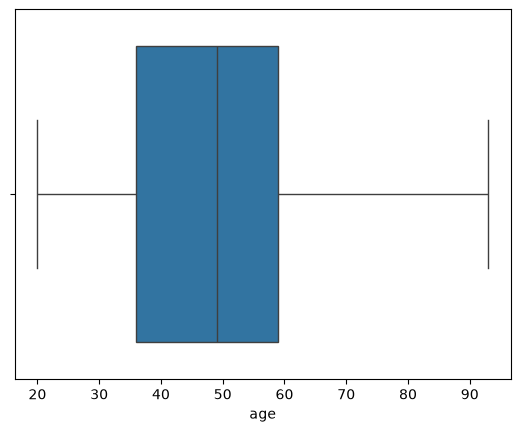

In [23]:
sns.boxplot(x=df['age'])
plt.show()

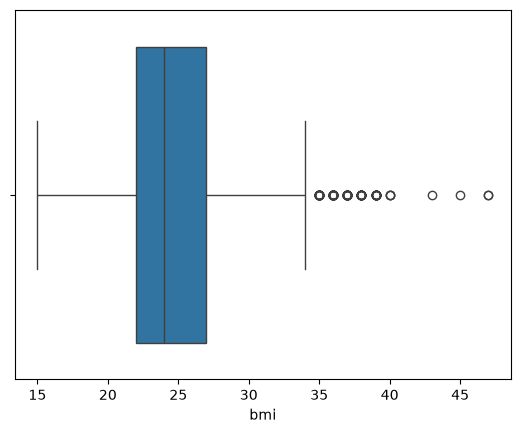

In [24]:
sns.boxplot(x=df['bmi'])
plt.show()

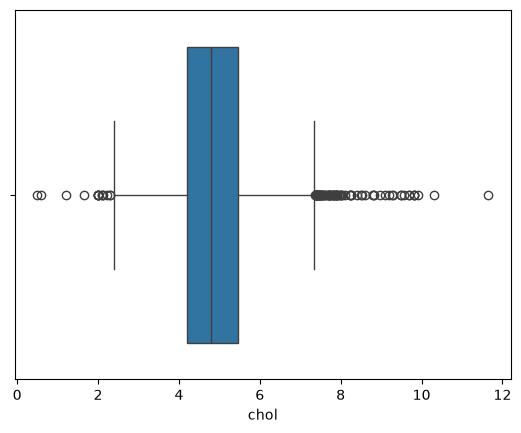

In [25]:
sns.boxplot(x=df['chol'])
plt.show()

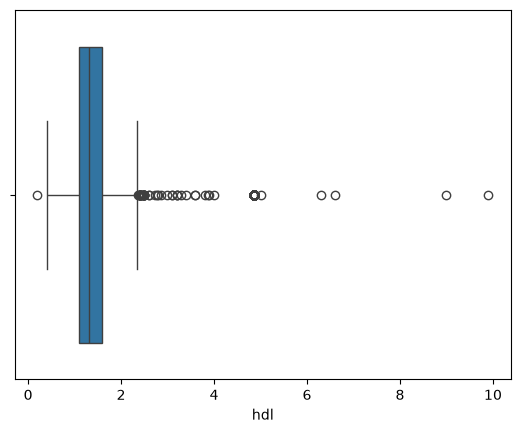

In [26]:
sns.boxplot(x=df['hdl'])
plt.show()

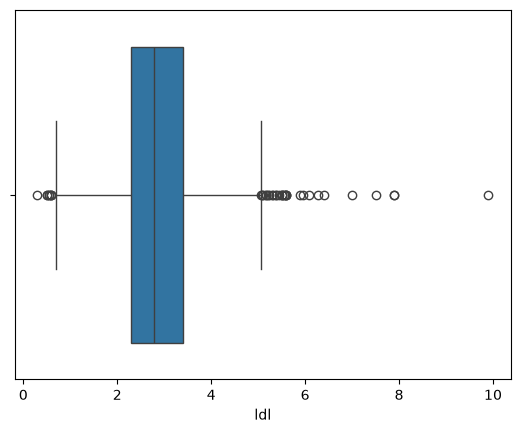

In [27]:
sns.boxplot(x=df['ldl'])
plt.show()

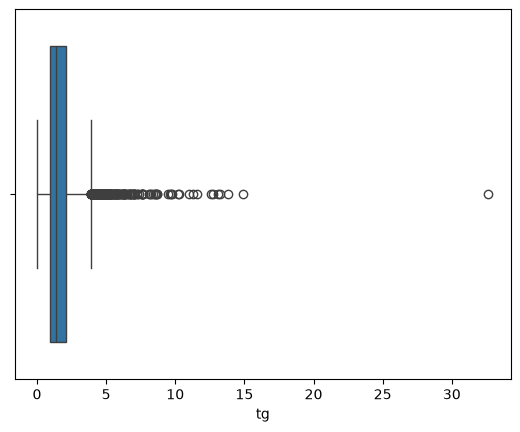

In [28]:
sns.boxplot(x=df['tg'])

plt.show()

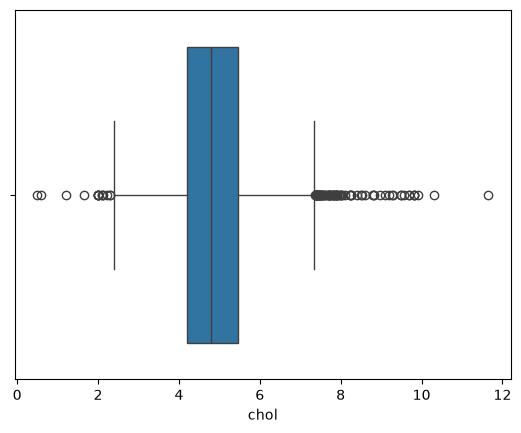

In [29]:

sns.boxplot(x=df['chol'])
plt.show()

(5129, 10)


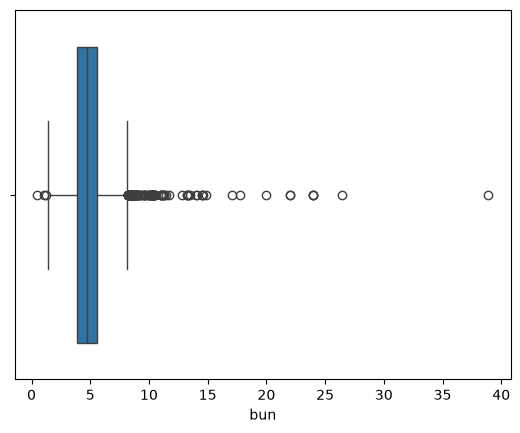

In [30]:
sns.boxplot(x=df['bun'])
print(df.shape)
plt.show()

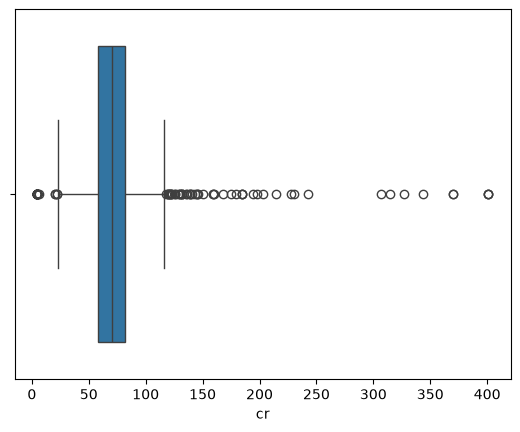

In [31]:
sns.boxplot(x=df['cr'])
plt.show()

In [32]:
print(df[df['cr']>700])

Empty DataFrame
Columns: [age, gender, bmi, chol, tg, hdl, ldl, cr, bun, diagnosis]
Index: []


In [33]:

iso_idx, lof_idx = outliersCheck(df)

df['anomaly_score'] = 0
df.loc[df.index.isin(iso_idx), 'anomaly_score'] += 1
df.loc[df.index.isin(lof_idx), 'anomaly_score'] += 1

ISOLATION FOREST:
Index([   7,   18,   41,   46,   49,   75,   91,   99,  147,  150,
       ...
       4934, 4949, 4997, 5007, 5011, 5038, 5039, 5108, 5113, 5120],
      dtype='int64', length=257)
(257, 11)
LOF:
Index([  10,   14,   45,   46,   49,   73,   84,   99,  133,  168,
       ...
       4934, 4971, 4997, 5033, 5039, 5058, 5063, 5086, 5113, 5120],
      dtype='int64', length=257)


In [34]:
df.describe()

,age,gender,bmi,chol,tg,hdl,ldl,cr,bun,diagnosis,anomaly_score
count,5129.000000,5129.000000,5129.000000,5129.000000,5129.000000,5129.000000,5129.000000,5129.000000,5129.000000,5129.00000,5129.000000
mean,48.945019,0.634237,24.608111,4.868033,1.723469,1.594627,2.914324,70.718486,4.887667,0.38799,0.100214
std,14.051141,0.481691,4.272785,0.998092,1.323959,1.038149,0.945065,22.392896,1.645309,0.48734,0.366416
min,20.000000,0.000000,15.000000,0.500000,0.030000,0.200000,0.300000,4.860753,0.500000,0.00000,0.000000
25%,36.000000,0.000000,22.000000,4.200000,0.910000,1.090000,2.290000,58.000000,3.900000,0.00000,0.000000
50%,49.000000,1.000000,24.000000,4.800000,1.380000,1.300000,2.790000,70.200000,4.720000,0.00000,0.000000
75%,59.000000,1.000000,27.000000,5.460000,2.100000,1.590000,3.400000,81.500000,5.600000,1.00000,0.000000
max,93.000000,1.000000,47.000000,11.650000,32.640000,9.900000,9.900000,401.000000,38.900000,1.00000,2.000000


In [ ]:
gender=df['gender']
df=df.drop('gender',axis=1)
Q1=df.quantile(.25)
Q2=df.quantile(.5)
Q3=df.quantile(.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

df[(df<lower_bound)|(df>upper_bound)]=np.nan
print(df.shape)
df=anomaly_imputer(df)

As we can see in the box plots theres lots of annomalies and outliers, dropping them its not an option because there are a lot and also the accuracy drops, imputing them also did not work because it also dropped the accuracy of the model, so sticking with the plain data!